In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
data_history = {
    'studentId': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Hannah', 'Ian', 'Jack', 
             'Kate', 'Leo', 'Lily', 'Max', 'Nora', 'Oliver', 'Penny', 'Quinn'],
    'historyMarks': [85, 90, 78, 92, 88, 85, 79, 83, 87, 91, 
                     84, 89, 82, 86, 88, 90, 81, 85],
    'age': [21, 22, 20, 23, 19, 24, 22, 21, 20, 18, 
            22, 23, 20, 24, 21, 19, 23, 22]
}

In [6]:
data_math = {
    'studentId': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 19, 20, 21, 22, 23, 24],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Hannah', 'Ian', 'Jack', 
             'Sophia', 'Emma', 'Finn', 'Gina', 'Henry', 'Ivy', 'Jake', 'Katie'],
    'mathMarks': [78, 85, 92, 89, 86, 90, 82, 79, 88, 94, 
                  87, 91, 80, 84, 89, 92, 83, 86],
    'age': [21, 22, 20, 23, 19, 24, 22, 21, 20, 18, 
            21, 20, 23, 19, 22, 24, 21, 23]
}

In [13]:
#bu iki dataseti dataframe halına gətirin.
history = pd.DataFrame(data_history)
math = pd.DataFrame(data_math)

In [15]:
history

,studentId,name,historyMarks,age
0,1,Alice,85,21
1,2,Bob,90,22
2,3,Charlie,78,20
3,4,David,92,23
4,5,Eve,88,19
5,6,Frank,85,24
6,7,Grace,79,22
7,8,Hannah,83,21
8,9,Ian,87,20
9,10,Jack,91,18


In [17]:
math

,studentId,name,mathMarks,age
0,1,Alice,78,21
1,2,Bob,85,22
2,3,Charlie,92,20
3,4,David,89,23
4,5,Eve,86,19
5,6,Frank,90,24
6,7,Grace,82,22
7,8,Hannah,79,21
8,9,Ian,88,20
9,10,Jack,94,18


In [24]:
#1)Hər iki fəndən imtahan verən tələbələrin hər iki fənndən olan ortalama ballarını çıxarın.
#(yeni bir sutun yaradin, ortalamalar orda olsun)
'''
inner_merged = pd.merge(df1, df2, on='Key', how='inner')
print("Inner Merge Result:")
print(inner_merged)
'''
inner_merged=pd.merge(history,math,on='name',how='inner')
#inner_merged

inner_merged["meann"]=(inner_merged["historyMarks"]+inner_merged["mathMarks"])/2

inner_merged

,studentId_x,name,historyMarks,age_x,studentId_y,mathMarks,age_y,meann
0,1,Alice,85,21,1,78,21,81.5
1,2,Bob,90,22,2,85,22,87.5
2,3,Charlie,78,20,3,92,20,85.0
3,4,David,92,23,4,89,23,90.5
4,5,Eve,88,19,5,86,19,87.0
5,6,Frank,85,24,6,90,24,87.5
6,7,Grace,79,22,7,82,22,80.5
7,8,Hannah,83,21,8,79,21,81.0
8,9,Ian,87,20,9,88,20,87.5
9,10,Jack,91,18,10,94,18,92.5


In [37]:
#2)Yalnız tarix fənnindən imtahan verən və yaşları 22+ olan tələbələrin minimum balını tapın.
'''
left_merged = pd.merge(df1, df2, on='Key', how='left')
print("\nLeft Merge Result:")
print(left_merged)
'''
left_merged=pd.merge(history,math,on='name',how='left')
#df_nans_only = df[df['column_name'].isna()]
onlyhist=left_merged[left_merged["mathMarks"].isna()]
onlyhist[onlyhist["age_x"]>22].min()[["historyMarks"]]


historyMarks    81
dtype: object

In [49]:
#3)Yalnız Riyaziyyat fənnindən imtahan verən tələbələrdən hansının maksimal bal topladığını tapın.
left_merged2=pd.merge(math,history,on='name',how='left')
left_merged2
onlymath=left_merged2[left_merged["mathMarks"].isna()]

onlymath.sort_values(by="mathMarks", ascending=False).head(1)

,studentId_x,name,mathMarks,age_x,studentId_y,historyMarks,age_y
15,22,Ivy,92,24,NaN,NaN,NaN


In [72]:
#4)Ümumilikdə imtahanlar erzinde hansı tələbələrin minimum və maksimum bal topladığını tapın (2 fenn uzre birlikde hesablayin).

outer_merged=pd.merge(history,math,on='name',how='outer')
outer_merged
outer_merged["summ"]=outer_merged["historyMarks"]+outer_merged["mathMarks"]
outer_merged
outer_merged['historyMarks'] = outer_merged['historyMarks'].fillna(0)
outer_merged['mathMarks'] = outer_merged['mathMarks'].fillna(0)
outer_merged["summ"]=outer_merged["historyMarks"]+outer_merged["mathMarks"]
outer_merged
#outer_merged.sort_values(by="summ", ascending=False).head(1)
outer_merged.sort_values(by="summ", ascending=True).head(1)

,studentId_x,name,historyMarks,age_x,studentId_y,mathMarks,age_y,summ
6,NaN,Finn,0.0,NaN,19.0,80.0,23.0,80.0


In [73]:
#5)Hər iki cədvəldən hansında yaş və bal arasında əlaqənin daha çox olduğunu tapın. digərindən çox olmasına rəğmən 
#sizcə diqqətə alınası əlaqədirmi?

# tarixde age ve historyMarks corelasiya
corr_history = history["age"].corr(history["historyMarks"])
print("tarixde yas bal elaqe:", corr_history)

# mathda age və mathMarks korelasiya
corr_math = math["age"].corr(math["mathMarks"])
print("mathda yas bal elaqe:", corr_math)
'''
bir az sanki var yas artiqca bal azalir
amma elaqe var dmeke duz deyil
'''

tarixde yas bal elaqe: -0.1271621003228433
mathda yas bal elaqe: -0.09288755387939876


'\nbir az sanki var yas artiqca bal azalir\n'

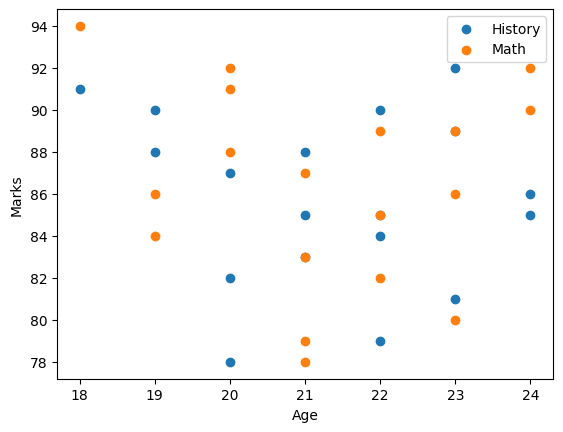

In [89]:
import matplotlib.pyplot as plt

plt.scatter(history["age"], history["historyMarks"],label='History')
plt.scatter(math["age"], math["mathMarks"],label='Math')

import matplotlib.pyplot as plt

plt.xlabel("Age")
plt.ylabel("Marks")

plt.legend()
plt.show()
